In [1]:
import numpy as np
import pandas as pd
import matplotlib
#matplotlib.use('Qtagg')
import matplotlib.pyplot as plt

import os
from scipy import*
from scipy import signal
from scipy.signal import find_peaks
row = np.arange(0,18,1)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
g = globals()
import matplotlib.colors as mcolors
from scipy.optimize import *
from itertools import *
from tqdm import tqdm
import seaborn as sns
from pathlib import Path
from numpy import sqrt, min,max,sin,cos
# from mpl_toolkits.axes_grid.anchored_artists import AnchoredSizeBar

In [171]:

# 定义数据文件的相对路径
data_file = Path("..") / ".."/"20250226" / "Confocal" / "20250226-0909-58_confocal_xy_data.dat"
# 确保路径正确解析
print(f"解析后的绝对路径: {data_file.resolve()}")

# 检查文件是否存在
if data_file.exists():
    print("文件存在，准备读取数据")
 # 读取文件
    data = pd.read_csv(data_file, delimiter="\t", skiprows=row)
    print(data.head())
else:
    print("error 文件不存在，请检查路径是否正确！")



# removing unwanted columns
data = data.drop(["count rate /Dev2/AI1 (Hz)","count rate /Dev2/AI0 (Hz)",'z position (m)',"Unnamed: 6"], axis='columns')
#visualise the data

# sort the data according to the prefence
# must be sorted for depth analysis
data_sort = data.sort_values(by=['#x position (m)'],ignore_index = True)


解析后的绝对路径: E:\Project_Code\Exp_results\Zhuoyu_Poling\20250226\Confocal\20250226-0909-58_confocal_xy_data.dat
文件存在，准备读取数据
   #x position (m)  y position (m)  z position (m)  \
0         0.000020         0.00012          0.0001   
1         0.000020         0.00012          0.0001   
2         0.000020         0.00012          0.0001   
3         0.000021         0.00012          0.0001   
4         0.000021         0.00012          0.0001   

   count rate /Dev2/Ctr3 (Hz)  count rate /Dev2/AI1 (Hz)  \
0                     28000.0                   4.874992   
1                     26600.0                   5.032227   
2                     25900.0                   5.095056   
3                     28700.0                   5.124661   
4                     20300.0                   5.145384   

   count rate /Dev2/AI0 (Hz)  Unnamed: 6  
0                   5.251962         NaN  
1                   5.165121         NaN  
2                   5.144397         NaN  
3                   5.

In [172]:
# Shifting the origin to (0,0) and rescale the coordinate to real distance
data['#x position (m)'] = (data['#x position (m)']-data['#x position (m)'].min())*1e6*0.606
data['y position (m)'] = ((data['y position (m)']-data['y position (m)'].min())*1e6)*0.368
data

,#x position (m),y position (m),count rate /Dev2/Ctr3 (Hz)
0,0.000000,0.00,28000.0
1,0.121351,0.00,26600.0
2,0.242703,0.00,25900.0
3,0.364054,0.00,28700.0
4,0.485406,0.00,20300.0
...,...,...,...
319995,96.474594,29.44,20300.0
319996,96.595915,29.44,12600.0
319997,96.717297,29.44,11900.0
319998,96.838618,29.44,11900.0


# Plot editted figure

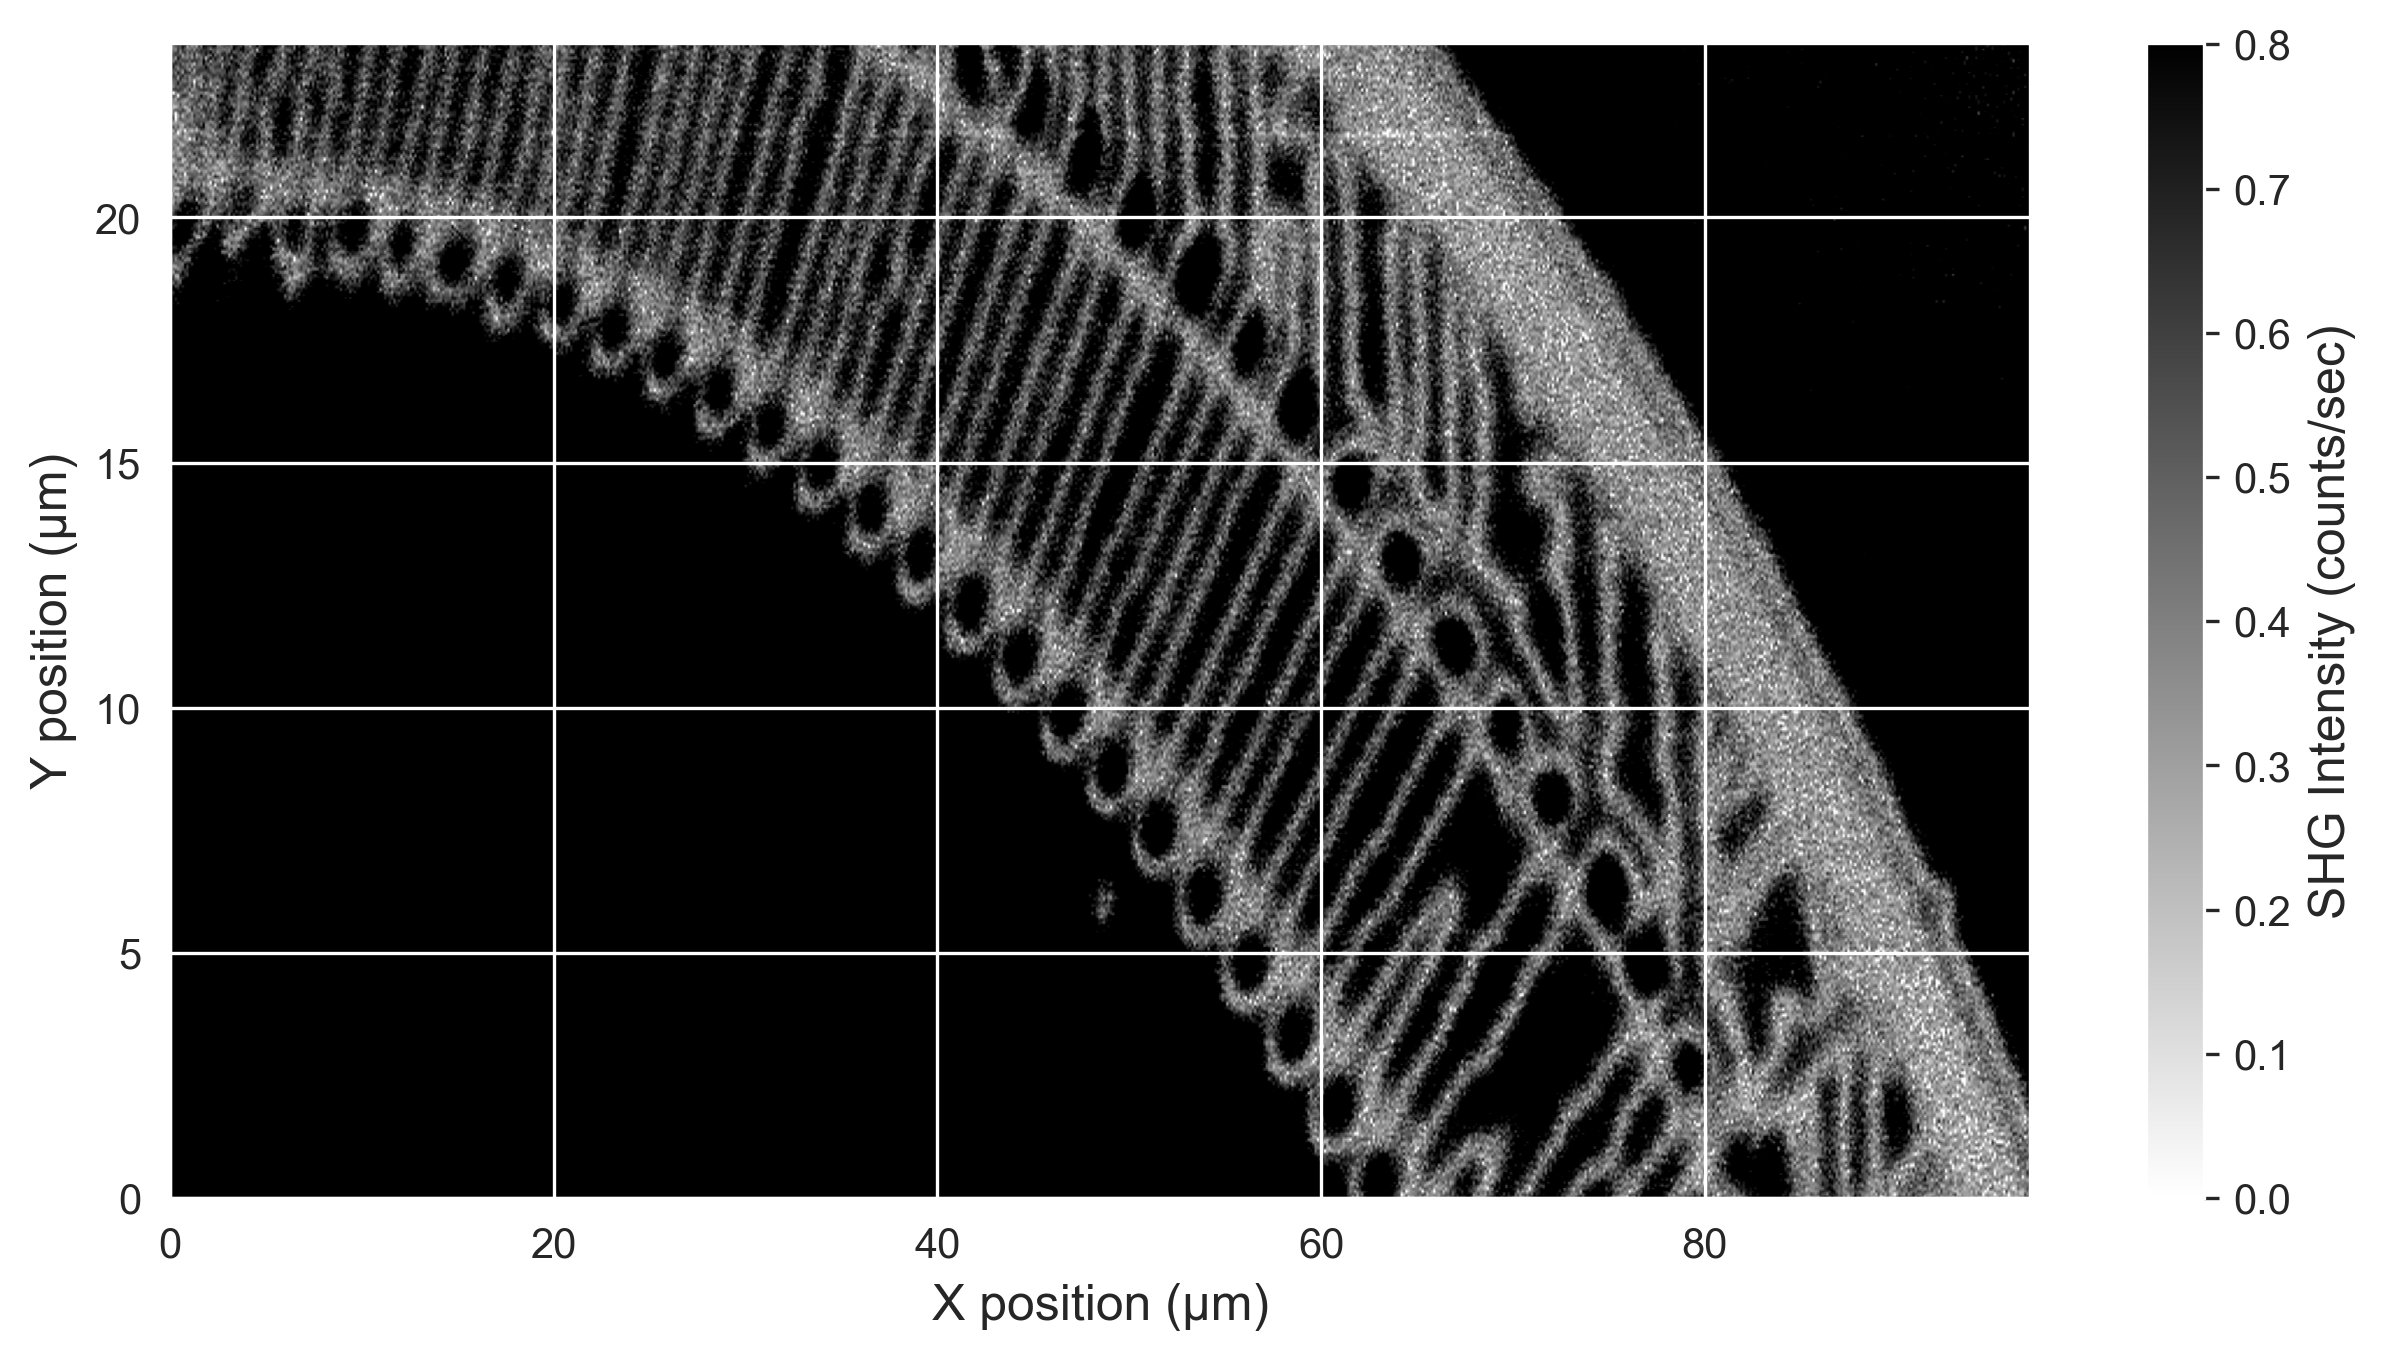

图片已保存到: E:\Project_Code\Exp_results\Zhuoyu_Poling\Editted_Fig\20250226-0909-58_confocal_xy_data_edited.png


In [173]:
import scipy.interpolate
# 自动生成保存路径
save_dir = Path("..") / ".." / "Editted_Fig"
save_dir.mkdir(parents=True, exist_ok=True)  # 确保目录存在

#  提取文件名，转换为 PNG
file_name = data_file.stem + "_edited.png"
save_path = save_dir / file_name

# 提取 X、Y、Z 数据
x = data['#x position (m)'].values   # 转换为 μm
y = data['y position (m)'].values
z = data['count rate /Dev2/Ctr3 (Hz)'].values  # 强度数据
z = sqrt(z)/sqrt(max(z))

# 计算 98% 最大值，避免极端点影响
v_max = np.percentile(z, 98)

# 构造规则网格
grid_x, grid_y = np.linspace(x.min(), x.max(), 800), np.linspace(y.min(), y.max(), 800)
grid_x, grid_y = np.meshgrid(grid_x, grid_y)

# 插值数据，使其适用于 imshow
grid_z = scipy.interpolate.griddata((x, y), z, (grid_x, grid_y), method='cubic')

# 画图
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
im = ax.imshow(grid_z*2, extent=[x.min(), x.max(), y.min(), y.max()*0.8], origin='lower',
               cmap='binary', aspect='auto', vmin=0, vmax=v_max)

# 添加 colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('SHG Intensity (counts/sec)', fontsize=12)

# 轴标签
ax.set_xlabel('X position (μm)', fontsize=12)
ax.set_ylabel('Y position (μm)', fontsize=12)

# 保存图片

plt.savefig(save_path, dpi=600, transparent=True, bbox_inches='tight')

plt.show()
print(f"图片已保存到: {save_path.resolve()}")

In [174]:
from scipy.signal.windows import gaussian
from scipy.signal import convolve


# 复制数据并筛选 poling 区域
df = data.copy()
df.drop(df[df['#x position (m)'] < 1].index, inplace=True)
df.drop(df[df['#x position (m)'] >20].index, inplace=True)
#df.drop(df[df['y position (m)'] > 15].index, inplace=True)
#df.drop(df[df['y position (m)'] < 5].index, inplace=True)

# 提取 X 位置 和 SHG 信号
x_data = df['#x position (m)'].values
shg_intensity = df['count rate /Dev2/Ctr3 (Hz)'].values  # SHG 计数

# **Step 1: 归一化 SHG 信号**
shg_intensity = np.sqrt(shg_intensity)  # SHG 强度 ∝ \( d_{33}^2 \)，取平方根
shg_intensity /= np.max(shg_intensity)  # 归一化到 [0,1]



df['shg_intensity'] = shg_intensity  # 把平滑后的数据加入 DataFrame 里
df


,#x position (m),y position (m),count rate /Dev2/Ctr3 (Hz),shg_intensity
9,1.092163,0.00,25900.0,0.697741
10,1.213515,0.00,31500.0,0.769484
11,1.334866,0.00,28700.0,0.734489
12,1.456218,0.00,25200.0,0.688247
13,1.577569,0.00,28700.0,0.734489
...,...,...,...,...
319360,19.416270,29.44,4900.0,0.303488
319361,19.537622,29.44,4200.0,0.280976
319362,19.658973,29.44,4200.0,0.280976
319363,19.780325,29.44,4900.0,0.303488


C:\Users\Steven Yu\AppData\Local\Temp\ipykernel_28972\2433624287.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels(ticklabs, fontsize=20)


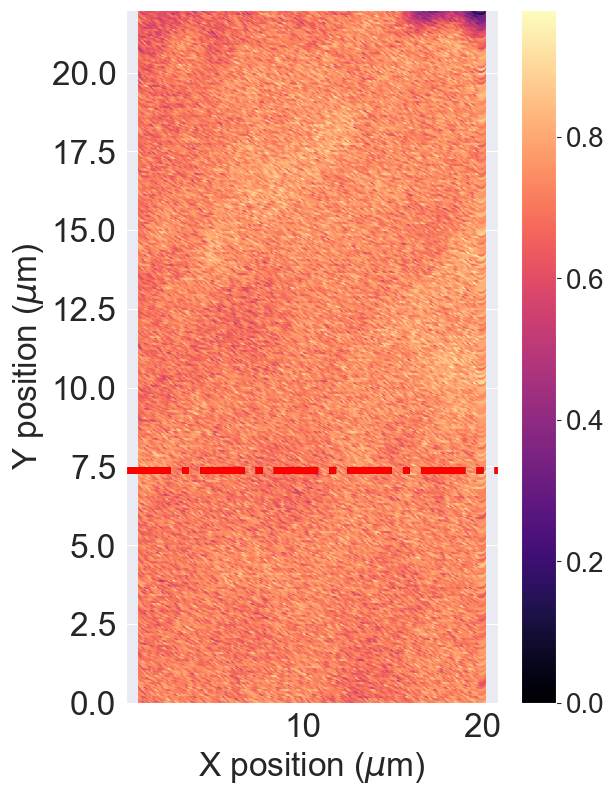

In [175]:

# here you verify the line you draw to see if you really get the electrode????
# md I wash the electrodes so hard to see the period or duty cycle
vmin = df['shg_intensity'].min()
#vmax = df['count rate /Dev2/Ctr3 (Hz)'].max()
vmax = 0.98
plt.figure(figsize=(6,9))

#define the line for electrode reference
y_e = round(4*(len(df))/16)

#plot the data
plt.scatter(x=df['#x position (m)'],y=df['y position (m)']
           ,c=df['shg_intensity'],cmap='magma',vmin=vmin,vmax=vmax)
plt.axhline(y = df['y position (m)'].iloc[y_e], color = 'black', linestyle = '-.',linewidth = 5)
plt.axhline(y = df['y position (m)'].iloc[round(4*(len(df))/16)], color = 'r', linestyle = '-.',linewidth = 5)
plt.ylim(0,22)
# plt.axis('off')
plt.xlabel('X position ($\mu$m)',size = 24)
plt.ylabel('Y position ($\mu$m)',size = 24)
plt.tick_params(axis='both', labelsize=24)
cbar = plt.colorbar()
ticklabs = cbar.ax.get_yticklabels()
cbar.ax.set_yticklabels(ticklabs, fontsize=20)
# cbar.ax.set_title('SHG intensity (counts/sec)',fontsize=20,rotation = 90)
plt.tick_params(axis='both', labelsize=24)


# Finding Electrodes

Poling Period 2T: 3.20 μm
Duty Cycle: 2.81
QPM Main Frequency: 0.2997 1/μm
QPM FFT Amplitude: 0.3877


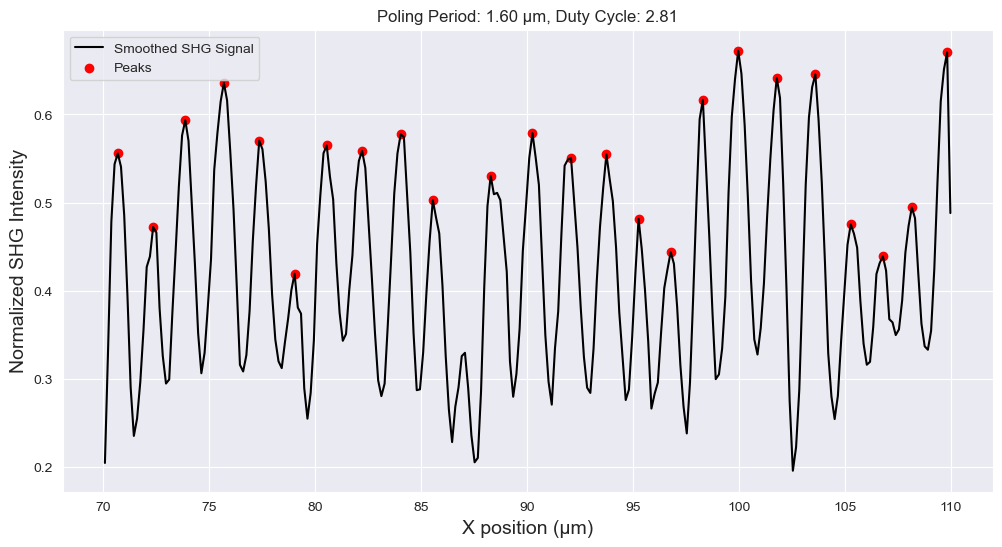

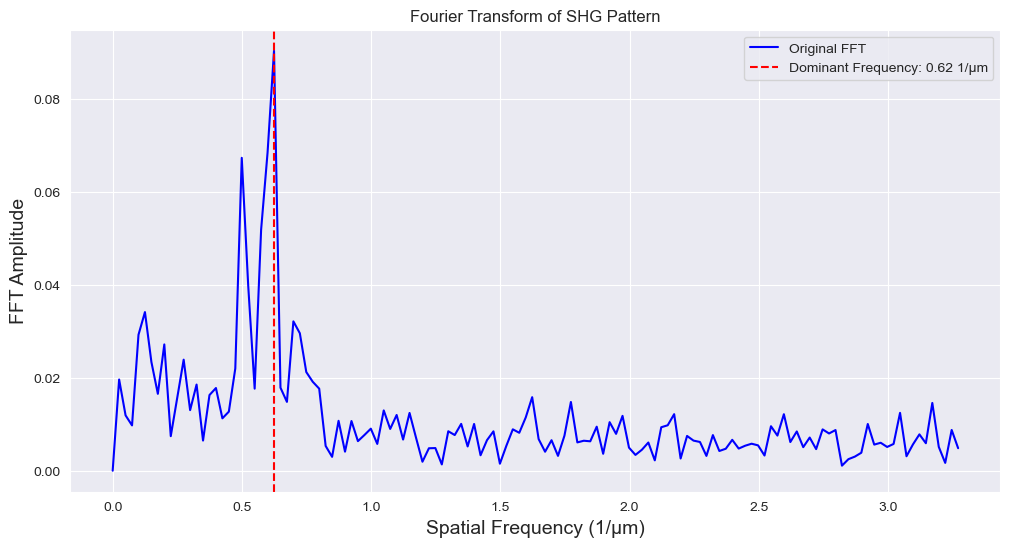

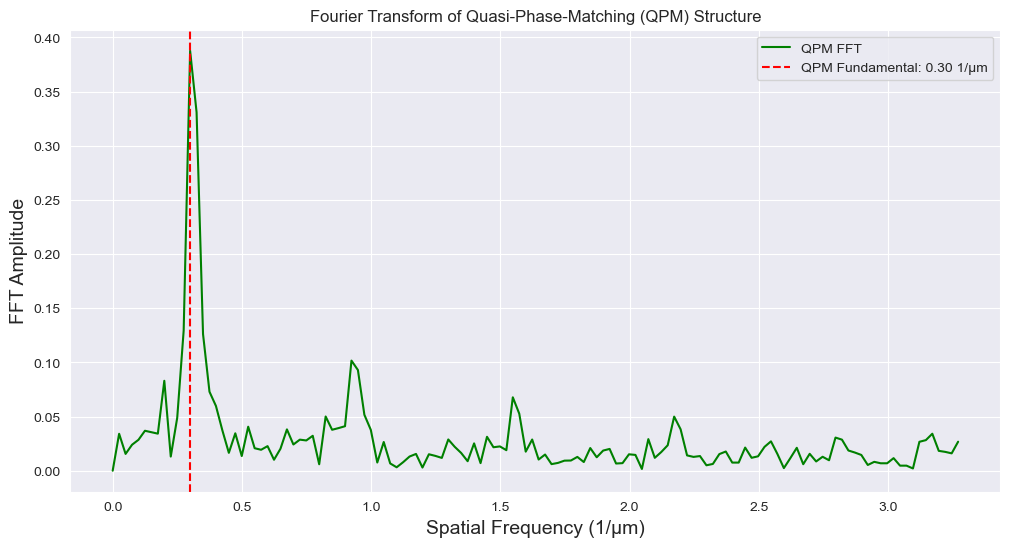

All images saved to: E:\Project_Code\Exp_results\Zhuoyu_Poling\Editted_Fig


In [169]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import convolve, find_peaks
from scipy.signal.windows import gaussian
from scipy.fftpack import fft, fftfreq

# **Step 1: 提取 X 方向数据**
X_e, Z_e = [], []
if y_e >= len(df):
    y_e = len(df) - 1  # 避免索引越界
y_ref = df["y position (m)"].iloc[y_e]

for i in range(len(df)):
    y = df["y position (m)"].iloc[i]
    if np.isclose(y, y_ref, atol=1e-10):
        x = df["#x position (m)"].iloc[i]
        z = df['shg_intensity'].iloc[i]  # 归一化后的 d33 值
        X_e.append(x)
        Z_e.append(z)

x_e = np.asarray(X_e)
z_e = np.asarray(Z_e)

# 确保数据非空
if len(x_e) == 0 or len(z_e) == 0:
    raise ValueError("Error: No valid data points found!")

# **Step 2: 高斯滤波去噪**

gauss_window = gaussian(4, std=3)  # 创建高斯平滑窗口
gauss_window /= gauss_window.sum()
z_e_smooth = convolve(z_e, gauss_window, mode='same')

# **Step 3: FFT 计算主要频率**
N = len(x_e)
fft_y = fft(z_e - np.mean(z_e))  # 计算FFT，去掉 DC 分量
freqs = fftfreq(N, d=(x_e[1] - x_e[0]))  # 计算频率轴
fft_amplitude = 2/N*np.abs(fft_y)

# 找到主频率分量
dominant_freq_idx = np.argmax(fft_amplitude[1:N//2])  # 跳过 DC 分量
dominant_freq = freqs[1:N//2][dominant_freq_idx]  # 获取主要空间频率
T = 1 / abs(dominant_freq)  # 计算周期（单位 μm）

# **Step 4: 计算占空比**
min_peak_distance = 1.2 / (x_e[1] - x_e[0])  # 计算对应的数据点数
peaks, _ = find_peaks(z_e_smooth, height=np.percentile(z_e_smooth, 50),distance=min_peak_distance)  # 50% 阈值寻找 peaks
if len(peaks) > 1:
    domain_widths = np.diff(peaks)  # 计算 poling 结构宽度
    duty_cycle = np.min(domain_widths) /2/ T  # 计算占空比
else:
    duty_cycle = None
# **Step 2: 计算占空比 (Duty Cycle)**
if T:
    duty_cycle = np.min(domain_widths) /2/ T  # 计算占空比
    print(f"Poling Period 2T: {2*T:.2f} μm")
    print(f"Duty Cycle: {duty_cycle:.2f}")
else:
    duty_cycle = None
    print("Error: Duty Cycle 计算失败")
# **Step 5: 反转 d_eff 符号**
deff_signs = np.sign(np.sin(2 * np.pi * dominant_freq/2 * x_e))  # 用正弦信号反转
z_e_reversed = z_e * deff_signs

# **Step 6: FFT 计算 QPM 结构**
fft_y_qpm = fft(z_e_reversed - np.mean(z_e_reversed))  # 计算 QPM 结构的 FFT
fft_amplitude_qpm = 2/N*np.abs(fft_y_qpm)
# 找到 QPM 结构的主要频率分量
qpm_peak_idx = np.argmax(fft_amplitude_qpm[1:N//2])  # 跳过 DC 分量
qpm_peak_freq = freqs[1:N//2][qpm_peak_idx]  # QPM 主要频率
qpm_peak_amplitude = fft_amplitude_qpm[qpm_peak_idx+1]  # QPM 对应幅度

# 打印结果
print(f"QPM Main Frequency: {qpm_peak_freq:.4f} 1/μm")
print(f"QPM FFT Amplitude: {qpm_peak_amplitude:.4f}")
# **自动生成文件名前缀**
file_prefix = data_file.stem  # 提取数据文件名

# **Step 7: 绘制并保存 SHG 信号**
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x_e, z_e_smooth, label="Smoothed SHG Signal", color="k")
ax.scatter(x_e[peaks], z_e_smooth[peaks], color='r', label="Peaks")
ax.set_xlabel("X position (μm)", size=14)
ax.set_ylabel("Normalized SHG Intensity", size=14)
ax.legend()
ax.set_title(f"Poling Period: {T:.2f} μm, Duty Cycle: {duty_cycle:.2f}" if duty_cycle else "No Period Detected")
fig.savefig(save_dir / f"{file_prefix}_SHG_signal.png", dpi=600, transparent=True, bbox_inches='tight')
plt.show()

# **Step 8: 绘制并保存 FFT 频谱**
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(freqs[:N//2], fft_amplitude[:N//2], color='b', label="Original FFT")
ax.axvline(x=dominant_freq, color='r', linestyle="--", label=f"Dominant Frequency: {dominant_freq:.2f} 1/μm")
ax.set_xlabel("Spatial Frequency (1/μm)", size=14)
ax.set_ylabel("FFT Amplitude", size=14)
ax.set_title("Fourier Transform of SHG Pattern")
ax.legend()
fig.savefig(save_dir / f"{file_prefix}_FFT.png", dpi=600, transparent=True, bbox_inches='tight')
plt.show()

# **Step 9: 绘制并保存 QPM 结构的 FFT 频谱**
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(freqs[:N//2], fft_amplitude_qpm[:N//2], color='g', label="QPM FFT")
ax.axvline(x=qpm_peak_freq, color='r', linestyle="--", label=f"QPM Fundamental: {qpm_peak_freq:.2f} 1/μm")
ax.set_xlabel("Spatial Frequency (1/μm)", size=14)
ax.set_ylabel("FFT Amplitude", size=14)
ax.set_title("Fourier Transform of Quasi-Phase-Matching (QPM) Structure")
ax.legend()
fig.savefig(save_dir / f"{file_prefix}_QPM_FFT.png", dpi=600, transparent=True, bbox_inches='tight')
plt.show()

print(f"All images saved to: {save_dir.resolve()}")


# prepare some parameters

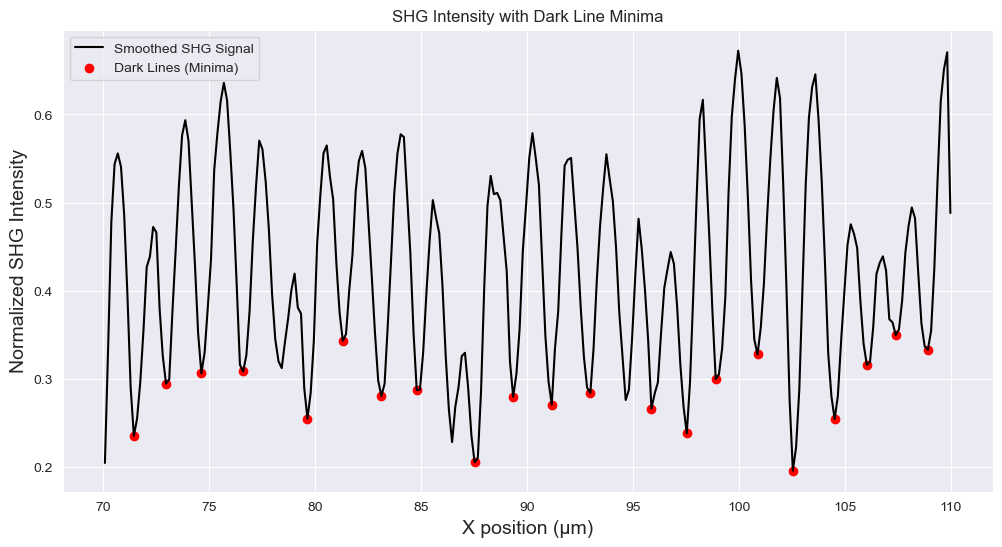

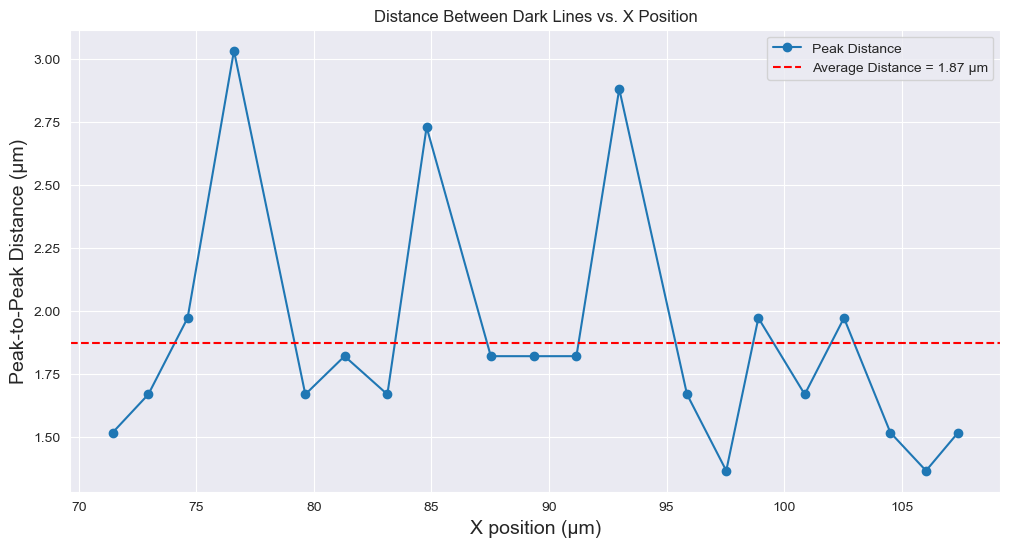

Duty Cycle: 0.36
All images saved to: E:\Project_Code\Exp_results\Zhuoyu_Poling\Processed_Figures


In [170]:
# **Step 2: 设定最小间距 distance = 0.9 μm**
min_peak_distance = 1.3 / (x_e[1] - x_e[0])  # 计算对应的数据点数
dark_peaks, _ = find_peaks(-z_e_smooth, distance=min_peak_distance)  # 找极小值

# **Step 3: 计算相邻 peak 之间的距离**
if len(dark_peaks) > 1:
    peak_distances = np.diff(x_e[dark_peaks])  # 计算两个极小值之间的间距
    avg_distance = np.mean(peak_distances)  # 计算平均周期
else:
    peak_distances = []
    avg_distance = None

# **自动生成文件名前缀**
file_prefix = data_file.stem  # 获取输入数据文件名
save_dir = Path("..") / ".." / "Processed_Figures"
save_dir.mkdir(parents=True, exist_ok=True)  # 确保目录存在

# **Step 4: 画出 SHG 信号 + 极小值**
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x_e, z_e_smooth, label="Smoothed SHG Signal", color="k")
ax.scatter(x_e[dark_peaks], z_e_smooth[dark_peaks], color='r', label="Dark Lines (Minima)")
ax.set_xlabel("X position (μm)", size=14)
ax.set_ylabel("Normalized SHG Intensity", size=14)
ax.legend()
ax.set_title("SHG Intensity with Dark Line Minima")

# **保存图像**
fig.savefig(save_dir / f"{file_prefix}_Dark_Lines.png", dpi=600, transparent=True, bbox_inches='tight')
plt.show()

# **Step 5: 画出 peak 之间的间距 vs X**
if len(peak_distances) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(x_e[dark_peaks[:-1]], peak_distances, marker='o', linestyle='-', label="Peak Distance")
    ax.axhline(y=avg_distance, color='r', linestyle="--", label=f"Average Distance = {avg_distance:.2f} μm")
    ax.set_xlabel("X position (μm)", size=14)
    ax.set_ylabel("Peak-to-Peak Distance (μm)", size=14)
    ax.legend()
    ax.set_title("Distance Between Dark Lines vs. X Position")

    # **保存图像**
    fig.savefig(save_dir / f"{file_prefix}_Peak_Distance.png", dpi=600, transparent=True, bbox_inches='tight')
    plt.show()
else:
    print("Error: Not enough peaks found to compute distances.")

# **Step 6: 计算占空比**
if avg_distance and len(peak_distances) > 0:
    duty_cycle = min(peak_distances) / (2 * avg_distance)
    print(f"Duty Cycle: {duty_cycle:.2f}")
else:
    print("Error: Cannot compute duty cycle")

print(f"All images saved to: {save_dir.resolve()}")


# Easily analyse the duty cycle vs distance from electrode tip

# here we draw lines to distinguish different domain????

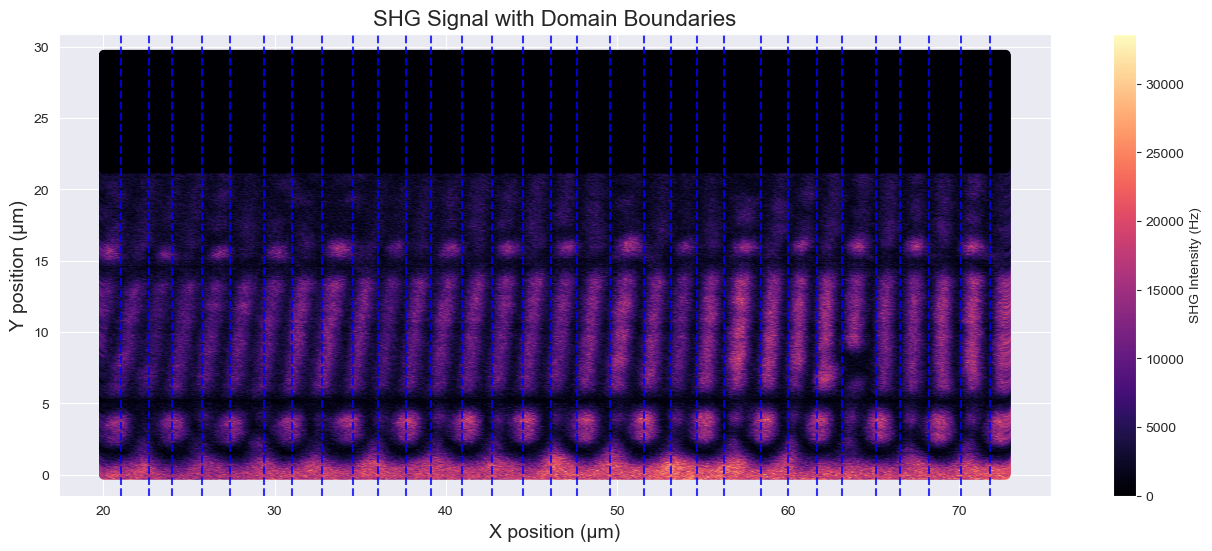

Image saved to: E:\Project_Code\Exp_results\Zhuoyu_Poling\Processed_Figures\20250225-2216-01_confocal_xy_data_Domain_Boundaries.png


In [52]:
plt.figure(figsize=(16, 6))

# 绘制原始 SHG 信号的散点图
plt.scatter(x=df['#x position (m)'], y=df['y position (m)'],
            c=df['count rate /Dev2/Ctr3 (Hz)'], cmap='magma')

# 在原图中标记极小值位置
for x in x_e[dark_peaks]:  # 这里 dark_peaks 是极小值的索引
    plt.axvline(x, linestyle='--', color='b', linewidth=1.5, alpha=0.8)

# 轴标签和标题
plt.xlabel("X position (μm)", size=14)
plt.ylabel("Y position (μm)", size=14)
plt.title("SHG Signal with Domain Boundaries", size=16)
plt.colorbar(label="SHG Intensity (Hz)")

# 显示图像
plt.show()
# **Step 4: 保存图片**
save_path = save_dir / f"{file_prefix}_Domain_Boundaries.png"
fig.savefig(save_path, dpi=600, transparent=True, bbox_inches='tight')

# **Step 5: 显示并打印保存路径**
plt.show()
print(f"Image saved to: {save_path.resolve()}")

